# Statistical Analysis of Physical Characteristics of Palmer Penguins
### Lab Problem Statement 6: Descriptive Statistics, Hypothesis Testing, ANOVA & Non-Parametric Tests

## Install and Load Required Packages

In [1]:
install.packages(c("moments", "car", "dplyr", "ggplot2"))
library(moments)
library(car)
library(dplyr)
library(ggplot2)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘colorspace’, ‘fracdiff’, ‘lmtest’, ‘timeDate’, ‘urca’, ‘zoo’, ‘RcppArmadillo’, ‘cowplot’, ‘Deriv’, ‘forecast’, ‘rbibutils’, ‘numDeriv’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘Rdpack’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘RcppEigen’, ‘carData’, ‘abind’, ‘Formula’, ‘pbkrtest’, ‘quantreg’, ‘lme4’


Loading required package: carData


Attaching package: ‘dplyr’


The following object is masked from ‘package:car’:

    recode


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




## Load Palmer Penguins Dataset from URL

In [2]:
url <- "https://raw.githubusercontent.com/allisonhorst/palmerpenguins/master/inst/extdata/penguins.csv"
penguins <- read.csv(url)
penguins <- na.omit(penguins)
penguins$species <- as.factor(penguins$species)
penguins$sex <- as.factor(penguins$sex)
str(penguins)
head(penguins)

'data.frame':	333 obs. of  8 variables:
 $ species          : Factor w/ 3 levels "Adelie","Chinstrap",..: 1 1 1 1 1 1 1 1 1 1 ...
 $ island           : chr  "Torgersen" "Torgersen" "Torgersen" "Torgersen" ...
 $ bill_length_mm   : num  39.1 39.5 40.3 36.7 39.3 38.9 39.2 41.1 38.6 34.6 ...
 $ bill_depth_mm    : num  18.7 17.4 18 19.3 20.6 17.8 19.6 17.6 21.2 21.1 ...
 $ flipper_length_mm: int  181 186 195 193 190 181 195 182 191 198 ...
 $ body_mass_g      : int  3750 3800 3250 3450 3650 3625 4675 3200 3800 4400 ...
 $ sex              : Factor w/ 2 levels "female","male": 2 1 1 1 2 1 2 1 2 2 ...
 $ year             : int  2007 2007 2007 2007 2007 2007 2007 2007 2007 2007 ...
 - attr(*, "na.action")= 'omit' Named int [1:11] 4 9 10 11 12 48 179 219 257 269 ...
  ..- attr(*, "names")= chr [1:11] "4" "9" "10" "11" ...


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
,<fct>,<chr>,<dbl>,<dbl>,<int>,<int>,<fct>,<int>
1,Adelie,Torgersen,39.1,18.7,181,3750,male,2007
2,Adelie,Torgersen,39.5,17.4,186,3800,female,2007
3,Adelie,Torgersen,40.3,18.0,195,3250,female,2007
5,Adelie,Torgersen,36.7,19.3,193,3450,female,2007
6,Adelie,Torgersen,39.3,20.6,190,3650,male,2007
7,Adelie,Torgersen,38.9,17.8,181,3625,female,2007


## Overall Descriptive Statistics of Body Mass

In [3]:
mean_bm <- mean(penguins$body_mass_g)
median_bm <- median(penguins$body_mass_g)
min_bm <- min(penguins$body_mass_g)
max_bm <- max(penguins$body_mass_g)
var_bm <- var(penguins$body_mass_g)
sd_bm <- sd(penguins$body_mass_g)
q1_bm <- quantile(penguins$body_mass_g, 0.25)
q3_bm <- quantile(penguins$body_mass_g, 0.75)
iqr_bm <- IQR(penguins$body_mass_g)
skew_bm <- skewness(penguins$body_mass_g)
kurt_bm <- kurtosis(penguins$body_mass_g)

cat("Mean:", mean_bm, "\n")
cat("Median:", median_bm, "\n")
cat("Min:", min_bm, "\n")
cat("Max:", max_bm, "\n")
cat("Variance:", var_bm, "\n")
cat("Standard Deviation:", sd_bm, "\n")
cat("Q1:", q1_bm, "\n")
cat("Q3:", q3_bm, "\n")
cat("IQR:", iqr_bm, "\n")
cat("Skewness:", skew_bm, "\n")
cat("Kurtosis:", kurt_bm, "\n")

Mean: 4207.057 
Median: 4050 
Min: 2700 
Max: 6300 
Variance: 648372.5 
Standard Deviation: 805.2158 
Q1: 3550 
Q3: 4775 
IQR: 1225 
Skewness: 0.4701162 
Kurtosis: 2.259514 


## Species-wise Descriptive Statistics of Body Mass

In [4]:
species_stats <- penguins %>%
  group_by(species) %>%
  summarise(
    Mean = mean(body_mass_g),
    Median = median(body_mass_g),
    Min = min(body_mass_g),
    Max = max(body_mass_g),
    Variance = var(body_mass_g),
    SD = sd(body_mass_g),
    Q1 = quantile(body_mass_g, 0.25),
    Q3 = quantile(body_mass_g, 0.75),
    IQR = IQR(body_mass_g),
    Skewness = skewness(body_mass_g),
    Kurtosis = kurtosis(body_mass_g)
  )
species_stats

species,Mean,Median,Min,Max,Variance,SD,Q1,Q3,IQR,Skewness,Kurtosis
<fct>,<dbl>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Adelie,3706.164,3700,2850,4775,210332.4,458.6201,3362.5,4000,637.5,0.2770077,2.411479
Chinstrap,3733.088,3700,2700,4800,147713.5,384.3351,3487.5,3950,462.5,0.2419413,3.463681
Gentoo,5092.437,5050,3950,6300,251478.3,501.4762,4700.0,5500,800.0,0.0449965,2.242850


## Histogram of Body Mass

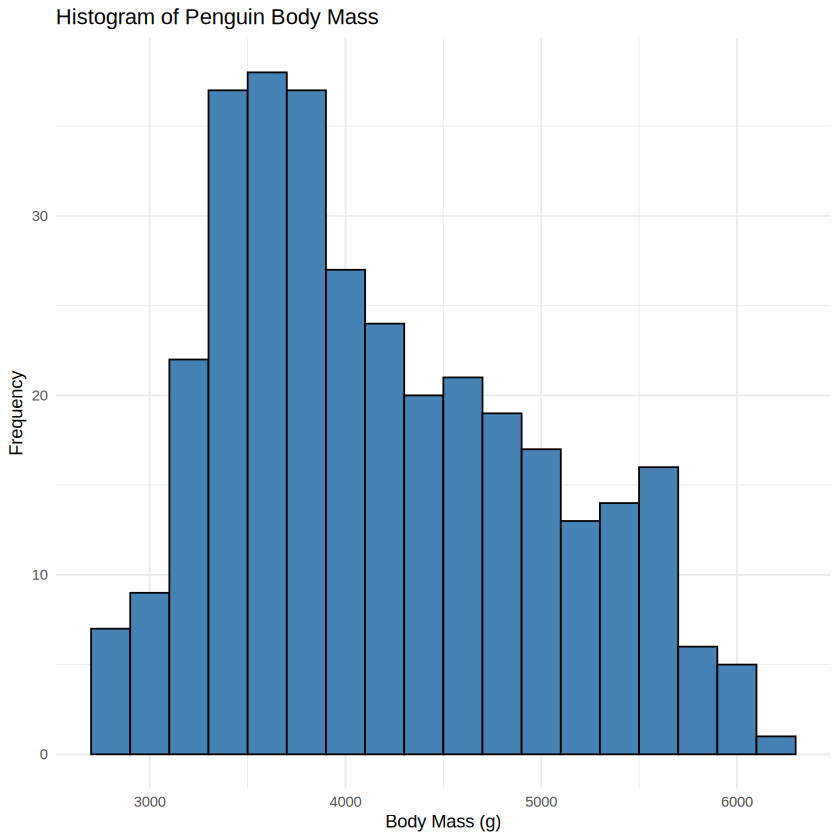

In [5]:
ggplot(penguins, aes(x = body_mass_g)) +
  geom_histogram(binwidth = 200, fill = "steelblue", color = "black") +
  labs(title = "Histogram of Penguin Body Mass",
       x = "Body Mass (g)", y = "Frequency") +
  theme_minimal()

## Boxplot of Body Mass by Species

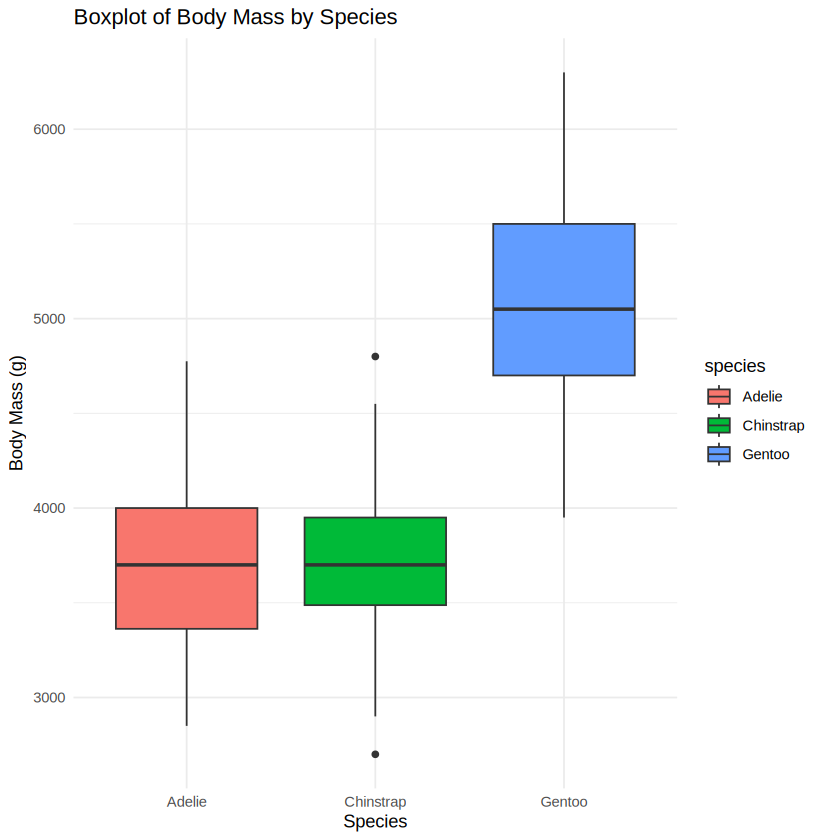

In [6]:
ggplot(penguins, aes(x = species, y = body_mass_g, fill = species)) +
  geom_boxplot() +
  labs(title = "Boxplot of Body Mass by Species",
       x = "Species", y = "Body Mass (g)") +
  theme_minimal()

## Density Plot of Body Mass by Species

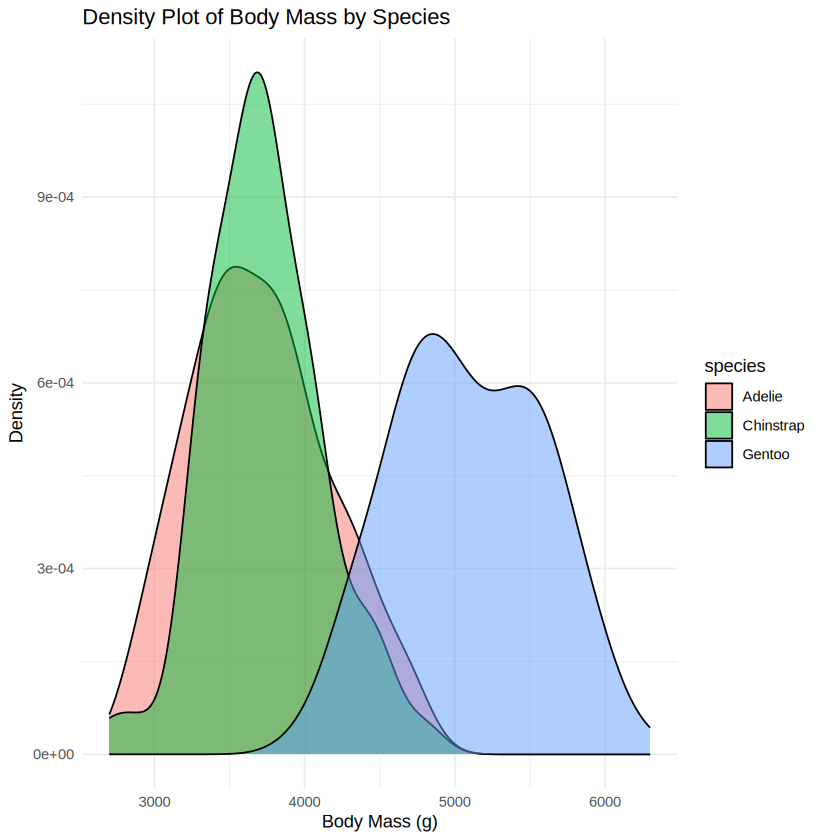

In [7]:
ggplot(penguins, aes(x = body_mass_g, fill = species)) +
  geom_density(alpha = 0.5) +
  labs(title = "Density Plot of Body Mass by Species",
       x = "Body Mass (g)", y = "Density") +
  theme_minimal()

## Hypothesis Statement for Body Mass Difference Between Sexes

In [8]:
cat("H0: There is no significant difference in mean body mass between male and female penguins\n")
cat("H1: There is a significant difference in mean body mass between male and female penguins\n")

H0: There is no significant difference in mean body mass between male and female penguins
H1: There is a significant difference in mean body mass between male and female penguins


## Normality Check Using Shapiro-Wilk Test

In [9]:
male_bm <- penguins$body_mass_g[penguins$sex == "male"]
female_bm <- penguins$body_mass_g[penguins$sex == "female"]

shapiro.test(male_bm)
shapiro.test(female_bm)


	Shapiro-Wilk normality test

data:  male_bm
W = 0.92504, p-value = 1.227e-07



	Shapiro-Wilk normality test

data:  female_bm
W = 0.91931, p-value = 6.155e-08


## QQ-Plots for Normality Check by Sex

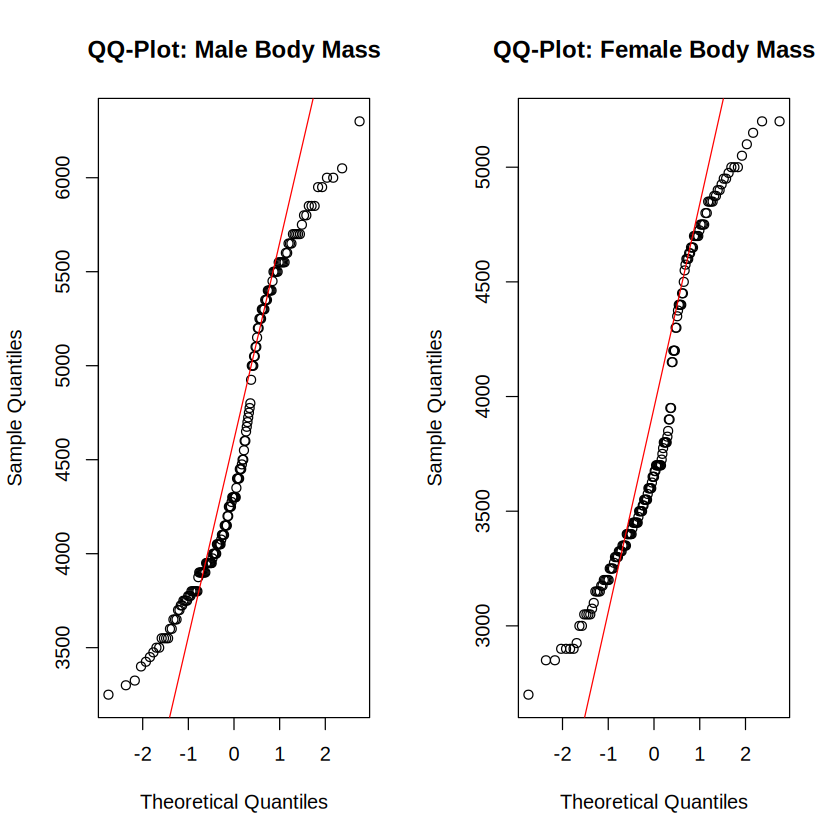

In [10]:
par(mfrow = c(1, 2))
qqnorm(male_bm, main = "QQ-Plot: Male Body Mass")
qqline(male_bm, col = "red")
qqnorm(female_bm, main = "QQ-Plot: Female Body Mass")
qqline(female_bm, col = "red")
par(mfrow = c(1, 1))

## Independent Two-Sample t-test for Body Mass by Sex

In [11]:
t_test_result <- t.test(body_mass_g ~ sex, data = penguins)
t_test_result


	Welch Two Sample t-test

data:  body_mass_g by sex
t = -8.5545, df = 323.9, p-value = 4.794e-16
alternative hypothesis: true difference in means between group female and group male is not equal to 0
95 percent confidence interval:
 -840.5783 -526.2453
sample estimates:
mean in group female   mean in group male 
            3862.273             4545.685 


## 95% Confidence Interval and Cohen's d Effect Size

In [12]:
ci_diff <- t_test_result$conf.int
cat("95% Confidence Interval for Difference in Means:", ci_diff, "\n")

pooled_sd <- sqrt(((length(male_bm) - 1) * var(male_bm) + (length(female_bm) - 1) * var(female_bm)) /
                     (length(male_bm) + length(female_bm) - 2))
cohens_d <- (mean(male_bm) - mean(female_bm)) / pooled_sd
cat("Cohen's d:", cohens_d, "\n")

95% Confidence Interval for Difference in Means: -840.5783 -526.2453 
Cohen's d: 0.9362048 


## Interpretation of Hypothesis Test Results
The p-value from the t-test indicates whether the null hypothesis of equal mean body mass between sexes is rejected. The 95% confidence interval shows the plausible range for the true difference in means, and Cohen's d quantifies the magnitude of the effect (0.2 = small, 0.5 = medium, 0.8 = large).

## Distribution of Body Mass Within Each Species

In [13]:
tapply(penguins$body_mass_g, penguins$species, summary)

$Adelie
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   2850    3362    3700    3706    4000    4775 

$Chinstrap
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   2700    3488    3700    3733    3950    4800 

$Gentoo
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   3950    4700    5050    5092    5500    6300 


## Normality Check for ANOVA Using QQ-Plots by Species

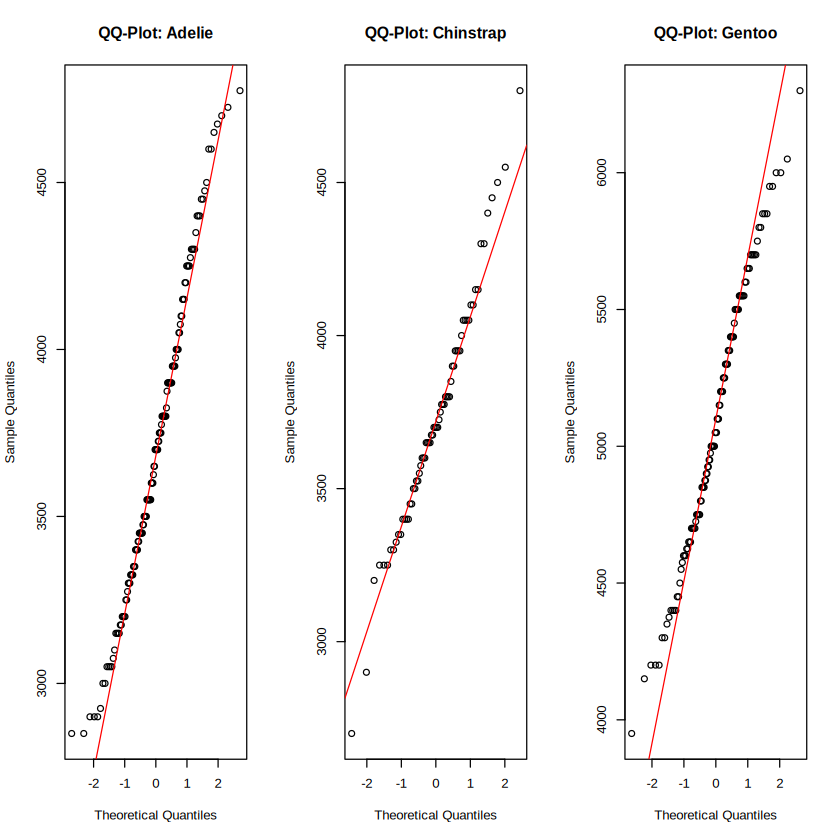

In [14]:
par(mfrow = c(1, 3))
for (sp in levels(penguins$species)) {
  qqnorm(penguins$body_mass_g[penguins$species == sp], main = paste("QQ-Plot:", sp))
  qqline(penguins$body_mass_g[penguins$species == sp], col = "red")
}
par(mfrow = c(1, 1))

## Normality Check for ANOVA Using Shapiro-Wilk Test by Species

In [15]:
tapply(penguins$body_mass_g, penguins$species, shapiro.test)

$Adelie

	Shapiro-Wilk normality test

data:  X[[i]]
W = 0.98116, p-value = 0.04232


$Chinstrap

	Shapiro-Wilk normality test

data:  X[[i]]
W = 0.98449, p-value = 0.5605


$Gentoo

	Shapiro-Wilk normality test

data:  X[[i]]
W = 0.98606, p-value = 0.2605



## Homogeneity of Variance Check Using Levene's Test

In [16]:
leveneTest(body_mass_g ~ species, data = penguins)

,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,2,5.134899,0.006367054
,330,NA,NA


## One-Way ANOVA: Body Mass Across Species

In [17]:
anova_model <- aov(body_mass_g ~ species, data = penguins)
summary(anova_model)

             Df    Sum Sq  Mean Sq F value Pr(>F)    
species       2 145190219 72595110   341.9 <2e-16 ***
Residuals   330  70069447   212332                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

## Tukey HSD Post-Hoc Test for Species Comparison

  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = body_mass_g ~ species, data = penguins)

$species
                       diff       lwr       upr    p adj
Chinstrap-Adelie   26.92385 -132.3528  186.2005 0.916431
Gentoo-Adelie    1386.27259 1252.2897 1520.2554 0.000000
Gentoo-Chinstrap 1359.34874 1194.4304 1524.2671 0.000000


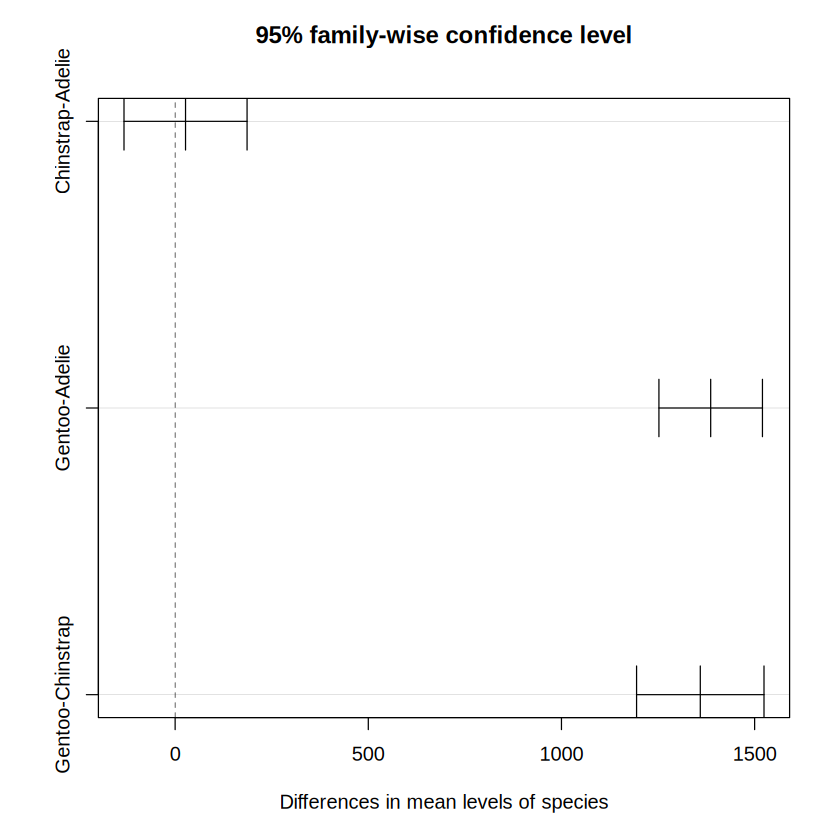

In [18]:
tukey_result <- TukeyHSD(anova_model)
tukey_result
plot(tukey_result)

## Kruskal-Wallis Non-Parametric Test: Body Mass Across Species

In [19]:
kruskal_result <- kruskal.test(body_mass_g ~ species, data = penguins)
kruskal_result


	Kruskal-Wallis rank sum test

data:  body_mass_g by species
Kruskal-Wallis chi-squared = 212.09, df = 2, p-value < 2.2e-16


## Comparison of ANOVA and Kruskal-Wallis Results
Both the one-way ANOVA and the Kruskal-Wallis test are compared to check whether the parametric and non-parametric approaches lead to the same conclusion regarding differences in body mass across species.

## Two-Way ANOVA: Effect of Species and Sex on Body Mass

In [20]:
two_way_model <- aov(body_mass_g ~ species * sex, data = penguins)
summary(two_way_model)

             Df    Sum Sq  Mean Sq F value   Pr(>F)    
species       2 145190219 72595110 758.358  < 2e-16 ***
sex           1  37090262 37090262 387.460  < 2e-16 ***
species:sex   2   1676557   838278   8.757 0.000197 ***
Residuals   327  31302628    95727                     
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

## Interpretation of Two-Way ANOVA Results
The two-way ANOVA output is used to determine whether species, sex, and their interaction significantly affect penguin body mass, based on the p-values of each term.

## Normality and Homogeneity Check for Flipper Length Across Species

In [21]:
tapply(penguins$flipper_length_mm, penguins$species, shapiro.test)
leveneTest(flipper_length_mm ~ species, data = penguins)

$Adelie

	Shapiro-Wilk normality test

data:  X[[i]]
W = 0.9934, p-value = 0.7427


$Chinstrap

	Shapiro-Wilk normality test

data:  X[[i]]
W = 0.98891, p-value = 0.8106


$Gentoo

	Shapiro-Wilk normality test

data:  X[[i]]
W = 0.96148, p-value = 0.00176



,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,2,0.4427865,0.6426253
,330,NA,NA


## One-Way ANOVA: Flipper Length Across Species

In [22]:
anova_flipper <- aov(flipper_length_mm ~ species, data = penguins)
summary(anova_flipper)

             Df Sum Sq Mean Sq F value Pr(>F)    
species       2  50526   25263   567.4 <2e-16 ***
Residuals   330  14693      45                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

## Tukey HSD Post-Hoc Test for Flipper Length

In [23]:
tukey_flipper <- TukeyHSD(anova_flipper)
tukey_flipper

  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = flipper_length_mm ~ species, data = penguins)

$species
                     diff       lwr       upr p adj
Chinstrap-Adelie  5.72079  3.414364  8.027215     0
Gentoo-Adelie    27.13255 25.192399 29.072709     0
Gentoo-Chinstrap 21.41176 19.023644 23.799885     0


## Kruskal-Wallis Test for Flipper Length Across Species

In [24]:
kruskal_flipper <- kruskal.test(flipper_length_mm ~ species, data = penguins)
kruskal_flipper


	Kruskal-Wallis rank sum test

data:  flipper_length_mm by species
Kruskal-Wallis chi-squared = 237.35, df = 2, p-value < 2.2e-16


## Species-wise Boxplot of Flipper Length

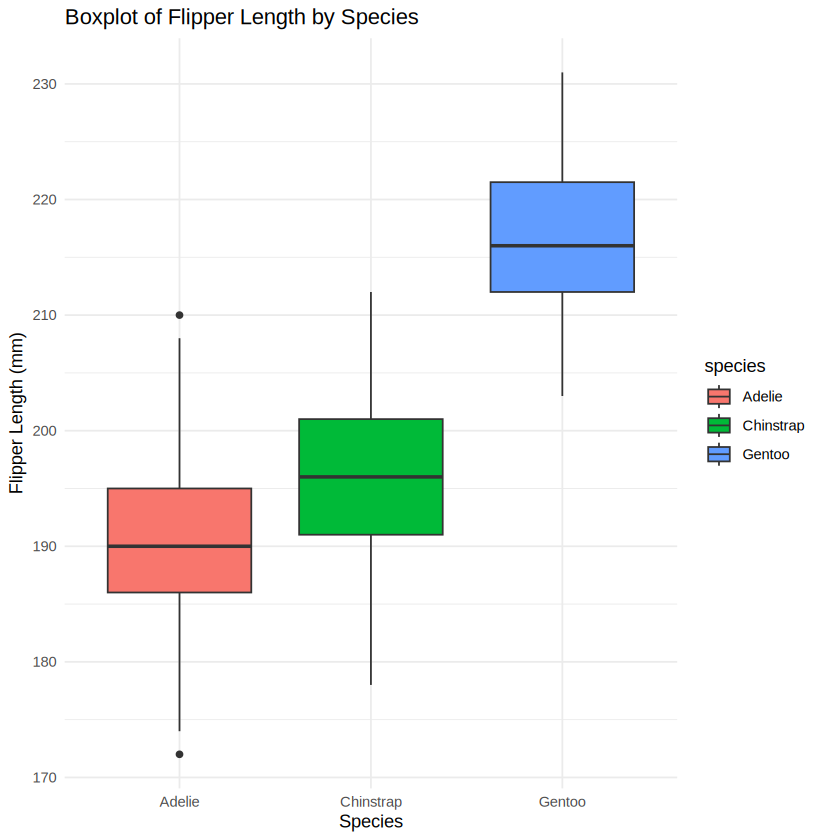

In [25]:
ggplot(penguins, aes(x = species, y = flipper_length_mm, fill = species)) +
  geom_boxplot() +
  labs(title = "Boxplot of Flipper Length by Species",
       x = "Species", y = "Flipper Length (mm)") +
  theme_minimal()

## Sex-wise Boxplot of Body Mass

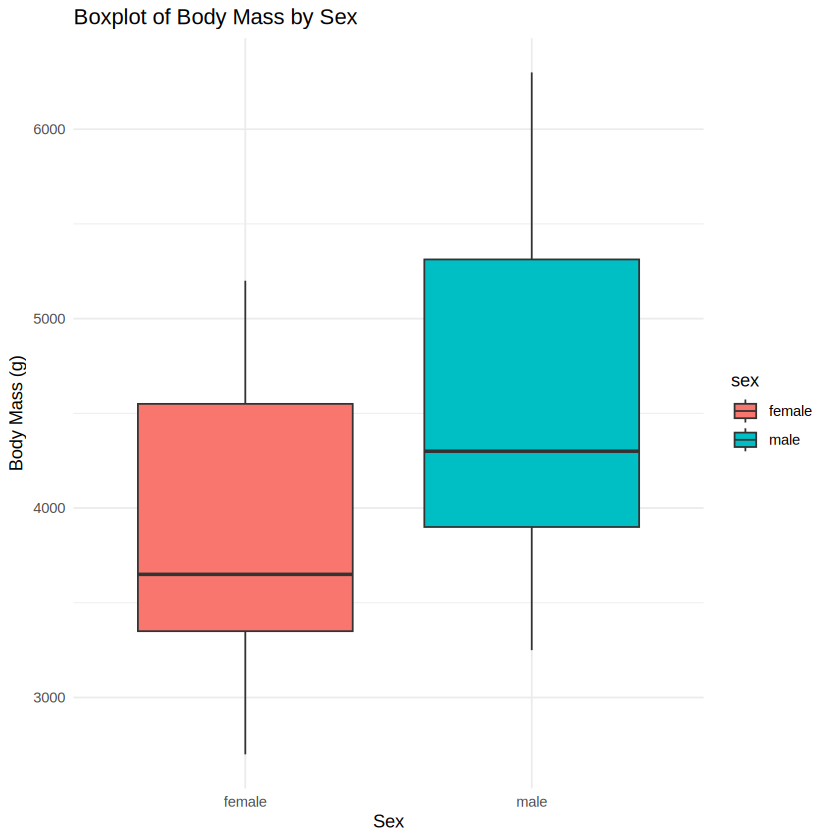

In [26]:
ggplot(penguins, aes(x = sex, y = body_mass_g, fill = sex)) +
  geom_boxplot() +
  labs(title = "Boxplot of Body Mass by Sex",
       x = "Sex", y = "Body Mass (g)") +
  theme_minimal()

## Group Comparison Plot Showing Significant Differences Among Species

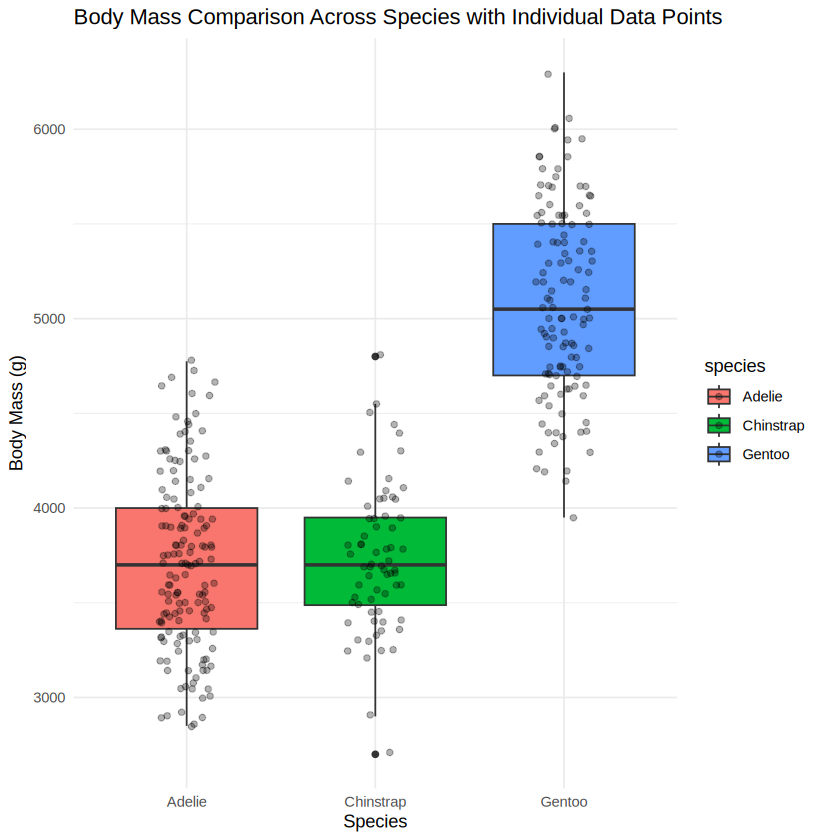

In [27]:
ggplot(penguins, aes(x = species, y = body_mass_g, fill = species)) +
  geom_boxplot() +
  geom_jitter(width = 0.15, alpha = 0.3) +
  labs(title = "Body Mass Comparison Across Species with Individual Data Points",
       x = "Species", y = "Body Mass (g)") +
  theme_minimal()

## Consistency Check Between Body Mass and Flipper Length Findings
The results of the flipper length analysis are compared with the earlier body mass findings to check whether both physical characteristics show consistent patterns of variation across the three penguin species.